In [28]:
import pandas as pd
import numpy as np

df = pd.read_csv("weather_linear_regression_10000.csv")

In [29]:
#understand the data 
df.head()
df.info()
df.columns
df.describe()
df.shape
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 10000 non-null  object 
 1   humidity_percent     10000 non-null  float64
 2   pressure_hpa         10000 non-null  float64
 3   wind_speed_kmph      10000 non-null  float64
 4   cloud_cover_percent  10000 non-null  float64
 5   rainfall_mm          10000 non-null  float64
 6   sunshine_hours       10000 non-null  float64
 7   temperature_c        10000 non-null  float64
dtypes: float64(7), object(1)
memory usage: 625.1+ KB


date                   0
humidity_percent       0
pressure_hpa           0
wind_speed_kmph        0
cloud_cover_percent    0
rainfall_mm            0
sunshine_hours         0
temperature_c          0
dtype: int64

date                   0
humidity_percent       0
pressure_hpa           0
wind_speed_kmph        0
cloud_cover_percent    0
rainfall_mm            0
sunshine_hours         0
temperature_c          0
dtype: int64


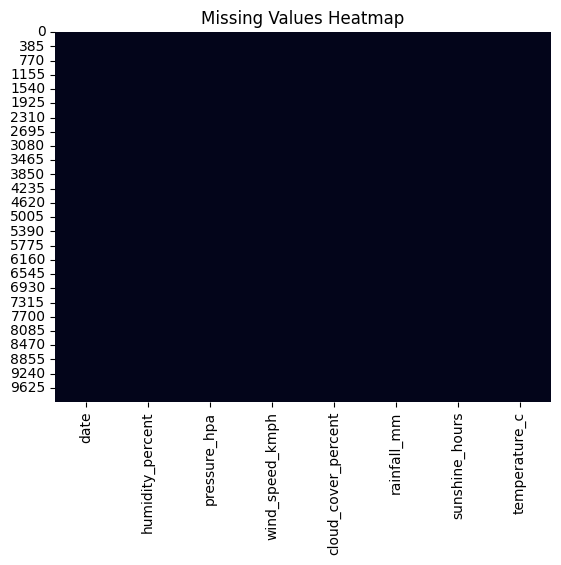

In [30]:
#list missing values
import seaborn as sns
import matplotlib.pyplot as plt

missing_values = df.isnull().sum() 
print(missing_values)
#visualize missing values 
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [31]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numeric Columns: ['humidity_percent', 'pressure_hpa', 'wind_speed_kmph', 'cloud_cover_percent', 'rainfall_mm', 'sunshine_hours', 'temperature_c']
Categorical Columns: ['date']


In [32]:
#fill missing values of numerical columns with median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("✓ Numerical columns filled with median")

✓ Numerical columns filled with median


In [33]:
#fill missing values of categorical columns with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("✓ Categorical columns filled with mode")

✓ Categorical columns filled with mode


In [34]:
#verify no missing values
print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
date                   0
humidity_percent       0
pressure_hpa           0
wind_speed_kmph        0
cloud_cover_percent    0
rainfall_mm            0
sunshine_hours         0
temperature_c          0
dtype: int64


In [35]:
# Map categorical columns to numeric
for col in cat_cols:
    print(f"Mapping {col}:")
    print(df[col].value_counts())
    print()

Mapping date:
date
2015-01-01    1
2015-01-02    1
2015-01-03    1
2015-01-04    1
2015-01-05    1
             ..
2042-05-14    1
2042-05-15    1
2042-05-16    1
2042-05-17    1
2042-05-18    1
Name: count, Length: 10000, dtype: int64



In [36]:
# Manual mapping for categorical columns
for col in cat_cols:
    df[col] = df[col].astype('category').cat.codes

print("✓ Categorical columns mapped to numeric")
print(df.head())

✓ Categorical columns mapped to numeric
   date  humidity_percent  pressure_hpa  wind_speed_kmph  cloud_cover_percent  \
0     0         49.963210   1006.154857        29.199932            63.814457   
1     1         96.057145   1003.303847         7.380480            45.929245   
2     2         78.559515    992.330774        13.865588            96.449852   
3     3         67.892679   1022.508667        26.531225            21.897845   
4     4         32.481491   1013.363691        19.283574            58.785642   

   rainfall_mm  sunshine_hours  temperature_c  
0    14.945602       10.166839          63.40  
1     4.740889        5.934205          59.14  
2     6.317961        2.345587          47.76  
3     9.033556        8.839701          65.66  
4    10.182667        5.024138          65.40  


In [37]:
# Final dataset verification
print("Final Dataset:")
print(df.shape)
print("\nMissing values:")
print(df.isnull().sum().sum())

Final Dataset:
(10000, 8)

Missing values:
0


In [38]:
# Data is ready for modeling
print("Data Preparation Complete!")
print(f"Shape: {df.shape}")

Data Preparation Complete!
Shape: (10000, 8)


In [39]:
# Linear Regression Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Define target variable (temperature) and features
X = df.drop(columns=['temperature_c', 'date'])
y = df['temperature_c']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTrain set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Features shape: (10000, 6)
Target shape: (10000,)

Train set size: 8000
Test set size: 2000


In [40]:
# Train Linear Regression Model
print("Training Linear Regression Model...")
print("="*50)

# Create and train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

print("✓ Model trained successfully!")


Training Linear Regression Model...
✓ Model trained successfully!


In [41]:
# Evaluate Model Performance
print("Model Evaluation:")
print("="*50)

# Calculate metrics for training data
train_mse = mean_squared_error(y_train, y_pred_train)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

print("Training Set Metrics:")
print(f"  MAE: {train_mae:.4f}")
print(f"  MSE: {train_mse:.4f}")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  R² Score: {train_r2:.4f}")

# Calculate metrics for testing data
test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

print("\nTest Set Metrics:")
print(f"  MAE: {test_mae:.4f}")
print(f"  MSE: {test_mse:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  R² Score: {test_r2:.4f}")

print("\n" + "="*50)
print("Model Coefficients:")
for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"  {feature}: {coef:.6f}")
print(f"  Intercept: {lr_model.intercept_:.6f}")


Model Evaluation:
Training Set Metrics:
  MAE: 1.2190
  MSE: 2.3277
  RMSE: 1.5257
  R² Score: 0.9550

Test Set Metrics:
  MAE: 1.1816
  MSE: 2.2103
  RMSE: 1.4867
  R² Score: 0.9576

Model Coefficients:
  humidity_percent: -0.150146
  pressure_hpa: 0.038673
  wind_speed_kmph: -0.100972
  cloud_cover_percent: -0.120171
  rainfall_mm: -0.249944
  sunshine_hours: 0.903229
  Intercept: 36.367317


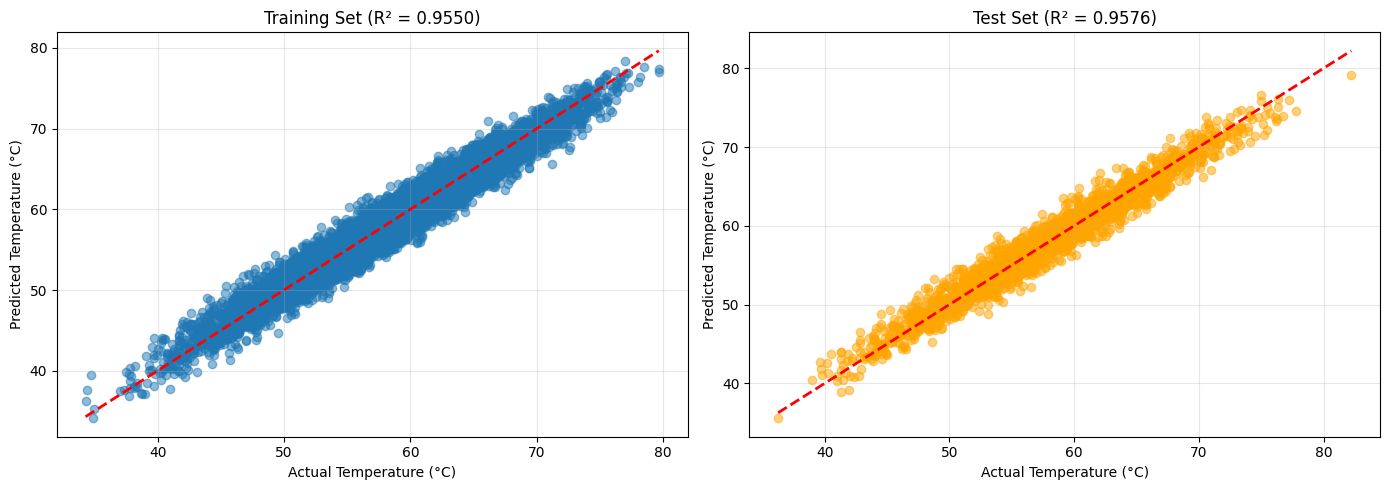

In [42]:
# Visualize predictions vs actual values
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training data
axes[0].scatter(y_train, y_pred_train, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Temperature (°C)')
axes[0].set_ylabel('Predicted Temperature (°C)')
axes[0].set_title(f'Training Set (R² = {train_r2:.4f})')
axes[0].grid(True, alpha=0.3)

# Testing data
axes[1].scatter(y_test, y_pred_test, alpha=0.5, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Temperature (°C)')
axes[1].set_ylabel('Predicted Temperature (°C)')
axes[1].set_title(f'Test Set (R² = {test_r2:.4f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Test with new weather data
print("Testing with new weather conditions:")
print("="*50)

# Create sample weather data
new_weather = pd.DataFrame({
    'humidity_percent': [65.0],
    'pressure_hpa': [1010.0],
    'wind_speed_kmph': [15.0],
    'cloud_cover_percent': [50.0],
    'rainfall_mm': [5.0],
    'sunshine_hours': [6.0]
})

print("\nNew Weather Data:")
print(new_weather)

# Make prediction
predicted_temp = lr_model.predict(new_weather)

print(f"\nPredicted Temperature: {predicted_temp[0]:.2f}°C")

# Test with another sample
print("\n" + "="*50)
print("Testing with another weather condition:")

new_weather2 = pd.DataFrame({
    'humidity_percent': [80.0],
    'pressure_hpa': [990.0],
    'wind_speed_kmph': [25.0],
    'cloud_cover_percent': [80.0],
    'rainfall_mm': [20.0],
    'sunshine_hours': [2.0]
})

print("\nNew Weather Data:")
print(new_weather2)

predicted_temp2 = lr_model.predict(new_weather2)

print(f"\nPredicted Temperature: {predicted_temp2[0]:.2f}°C")


Testing with new weather conditions:

New Weather Data:
   humidity_percent  pressure_hpa  wind_speed_kmph  cloud_cover_percent  \
0              65.0        1010.0             15.0                 50.0   

   rainfall_mm  sunshine_hours  
0          5.0             6.0  

Predicted Temperature: 62.31°C

Testing with another weather condition:

New Weather Data:
   humidity_percent  pressure_hpa  wind_speed_kmph  cloud_cover_percent  \
0              80.0         990.0             25.0                 80.0   

   rainfall_mm  sunshine_hours  
0         20.0             2.0  

Predicted Temperature: 47.31°C
